In [1]:
# ============================================
#  FEATURE ENGINEERING
# ============================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load master dataset
master = pd.read_csv('data/master_dataset.csv')
print(f"✅ Loaded: {master.shape}")
print(master.columns.tolist())

# ============================================
# SELECT RELEVANT FEATURES
# ============================================
# Keep only useful columns for ML
features = [
    'UserId', 'VisitYear', 'VisitMonth',
    'AttractionId', 'Rating', 'VisitModeId',
    'ContinentId', 'RegionId', 'CountryId', 'CityId',
    'Continent', 'Region', 'Country', 'CityName',
    'Attraction', 'AttractionType', 'VisitModeName'
]

df = master[features].copy()
print(f"\n✅ Selected features shape: {df.shape}")
print(df.dtypes)

# ============================================
# ENCODE CATEGORICAL COLUMNS
# ============================================
le = LabelEncoder()

# Encode text columns
cat_cols = ['Continent', 'Region', 'Country', 
            'CityName', 'AttractionType', 'VisitModeName']

for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    print(f"✅ Encoded: {col}")

# ============================================
# CREATE FEATURE SETS FOR EACH MODEL
# ============================================

# Common encoded feature columns
encoded_features = [
    'VisitYear', 'VisitMonth',
    'ContinentId', 'RegionId', 'CountryId', 'CityId',
    'AttractionId', 'VisitModeId',
    'Continent_enc', 'Region_enc', 'Country_enc',
    'CityName_enc', 'AttractionType_enc'
]

# --- MODEL 1: REGRESSION (Predict Rating) ---
X_reg = df[encoded_features]
y_reg = df['Rating']
print(f"\n✅ Regression — X: {X_reg.shape}, y: {y_reg.shape}")

# --- MODEL 2: CLASSIFICATION (Predict VisitMode) ---
X_cls = df[encoded_features]
y_cls = df['VisitModeId']
print(f"✅ Classification — X: {X_cls.shape}, y: {y_cls.shape}")

print("\n✅ Feature Engineering Complete!")
print(f"\nSample encoded data:")
print(df[encoded_features].head(3))

✅ Loaded: (52922, 18)
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitModeId', 'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'CityName', 'Country', 'Region', 'Continent', 'Attraction', 'AttractionType', 'VisitModeName']

✅ Selected features shape: (52922, 17)
UserId             int64
VisitYear          int64
VisitMonth         int64
AttractionId       int64
Rating             int64
VisitModeId        int64
ContinentId        int64
RegionId           int64
CountryId          int64
CityId             int64
Continent         object
Region            object
Country           object
CityName          object
Attraction        object
AttractionType    object
VisitModeName     object
dtype: object
✅ Encoded: Continent
✅ Encoded: Region
✅ Encoded: Country
✅ Encoded: CityName
✅ Encoded: AttractionType
✅ Encoded: VisitModeName

✅ Regression — X: (52922, 13), y: (52922,)
✅ Classification — X: (52922, 13), y: (52922,)

✅ Feature Engineering Complete!

Samp

MODEL 1: REGRESSION — Predicting Rating

Linear Regression:
  R²   : 0.0346
  MSE  : 0.9173
  RMSE : 0.9578

Random Forest Regressor:
  R²   : 0.0521
  MSE  : 0.9006
  RMSE : 0.9490

✅ Best Regression Model saved!

MODEL 2: CLASSIFICATION — Predicting Visit Mode

Logistic Regression:
  Accuracy : 0.5619
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       135
           2       0.65      0.88      0.75      4337
           3       0.42      0.44      0.43      2995
           4       0.53      0.33      0.41      2190
           5       0.48      0.08      0.13       928

    accuracy                           0.56     10585
   macro avg       0.42      0.35      0.34     10585
weighted avg       0.54      0.56      0.52     10585


Random Forest Classifier:
  Accuracy : 1.0000
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       135
           2       1.00      1.00      1.00      4

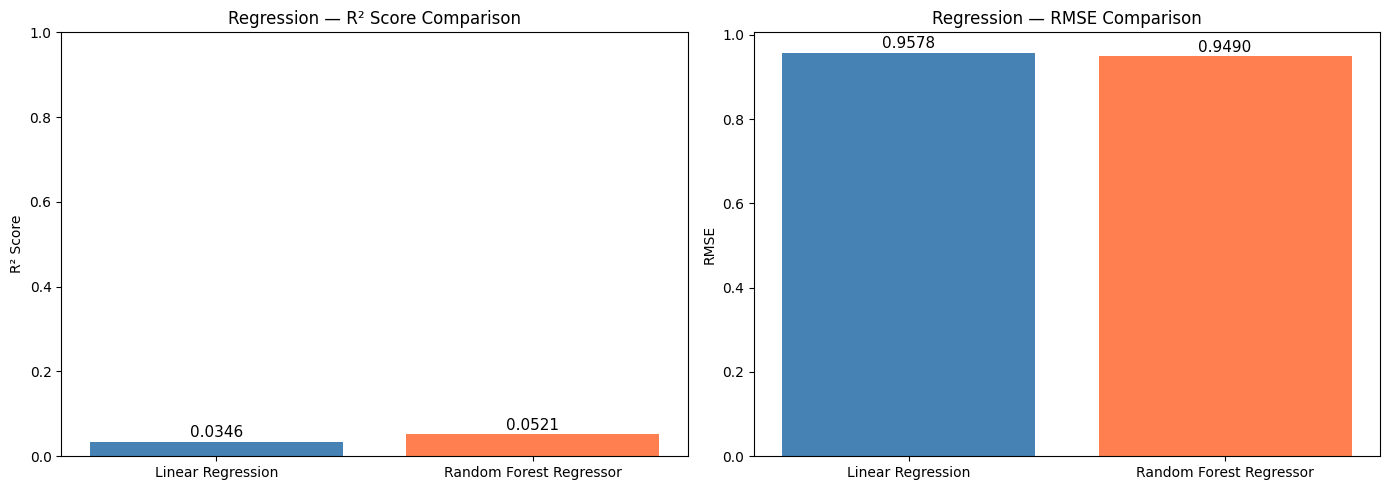

✅ Regression comparison plot saved!


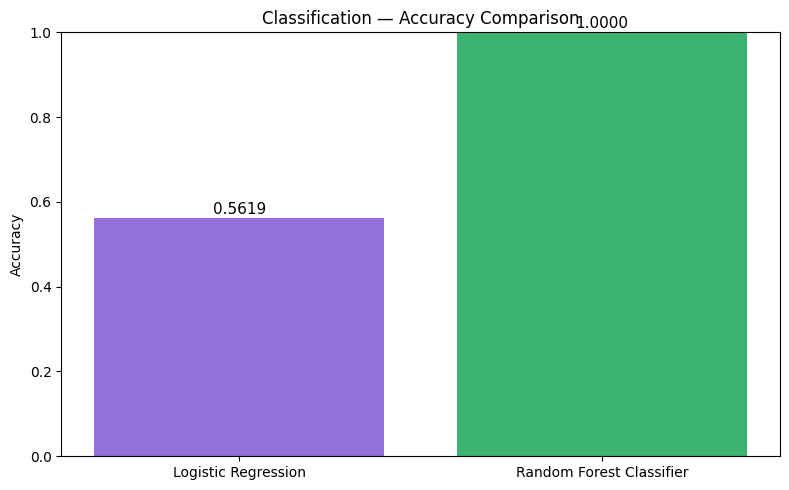

✅ Classification comparison plot saved!

✅ ALL MODELS TRAINED & SAVED!


In [2]:
# ============================================
#  MODEL BUILDING
# ============================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# ============================================
# MODEL 1: REGRESSION - Predict Rating
# ============================================
print("=" * 50)
print("MODEL 1: REGRESSION — Predicting Rating")
print("=" * 50)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

# Train Multiple Regression Models
models_reg = {
    'Linear Regression'       : LinearRegression(),
    'Random Forest Regressor' : RandomForestRegressor(
                                    n_estimators=100, random_state=42)
}

reg_results = {}
for name, model in models_reg.items():
    model.fit(X_train_r, y_train_r)
    y_pred = model.predict(X_test_r)
    r2  = r2_score(y_test_r, y_pred)
    mse = mean_squared_error(y_test_r, y_pred)
    rmse = np.sqrt(mse)
    reg_results[name] = {'R2': r2, 'MSE': mse, 'RMSE': rmse}
    print(f"\n{name}:")
    print(f"  R²   : {r2:.4f}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")

# Save best regression model (Random Forest)
best_reg_model = models_reg['Random Forest Regressor']
with open('models/regression_model.pkl', 'wb') as f:
    pickle.dump(best_reg_model, f)
print("\n✅ Best Regression Model saved!")

# ============================================
# MODEL 2: CLASSIFICATION - Predict VisitMode
# ============================================
print("\n" + "=" * 50)
print("MODEL 2: CLASSIFICATION — Predicting Visit Mode")
print("=" * 50)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42)

# Train Multiple Classification Models
models_cls = {
    'Logistic Regression'       : LogisticRegression(
                                    max_iter=1000, random_state=42),
    'Random Forest Classifier'  : RandomForestClassifier(
                                    n_estimators=100, random_state=42)
}

cls_results = {}
for name, model in models_cls.items():
    model.fit(X_train_c, y_train_c)
    y_pred = model.predict(X_test_c)
    acc = accuracy_score(y_test_c, y_pred)
    cls_results[name] = {'Accuracy': acc}
    print(f"\n{name}:")
    print(f"  Accuracy : {acc:.4f}")
    print(classification_report(y_test_c, y_pred))

# Save best classification model (Random Forest)
best_cls_model = models_cls['Random Forest Classifier']
with open('models/classification_model.pkl', 'wb') as f:
    pickle.dump(best_cls_model, f)
print("✅ Best Classification Model saved!")

# ============================================
# MODEL COMPARISON PLOTS
# ============================================

# Plot 1: Regression Model Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 Scores
names = list(reg_results.keys())
r2_scores = [reg_results[n]['R2'] for n in names]
axes[0].bar(names, r2_scores, color=['steelblue', 'coral'])
axes[0].set_title('Regression — R² Score Comparison')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11)

# RMSE Scores
rmse_scores = [reg_results[n]['RMSE'] for n in names]
axes[1].bar(names, rmse_scores, color=['steelblue', 'coral'])
axes[1].set_title('Regression — RMSE Comparison')
axes[1].set_ylabel('RMSE')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('data/plot9_regression_comparison.png')
plt.show()
print("✅ Regression comparison plot saved!")

# Plot 2: Classification Model Comparison
plt.figure(figsize=(8, 5))
cls_names = list(cls_results.keys())
acc_scores = [cls_results[n]['Accuracy'] for n in cls_names]
plt.bar(cls_names, acc_scores, color=['mediumpurple', 'mediumseagreen'])
plt.title('Classification — Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, v in enumerate(acc_scores):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('data/plot10_classification_comparison.png')
plt.show()
print("✅ Classification comparison plot saved!")

print("\n✅ ALL MODELS TRAINED & SAVED!")

In [ ]:
# ============================================
# FIXED FEATURE ENGINEERING
# ============================================

# Reload fresh
df = master.copy()

# ============================================
# ADD MEANINGFUL FEATURES
# ============================================

# 1. User's average rating (how generous is this user?)
user_avg_rating = df.groupby('UserId')['Rating'].mean()
df['user_avg_rating'] = df['UserId'].map(user_avg_rating)

# 2. Attraction's average rating (how good is this attraction?)
attr_avg_rating = df.groupby('AttractionId')['Rating'].mean()
df['attr_avg_rating'] = df['AttractionId'].map(attr_avg_rating)

# 3. Attraction's visit count (how popular?)
attr_visit_count = df.groupby('AttractionId')['TransactionId'].count()
df['attr_visit_count'] = df['AttractionId'].map(attr_visit_count)

# 4. User's visit count (how experienced?)
user_visit_count = df.groupby('UserId')['TransactionId'].count()
df['user_visit_count'] = df['UserId'].map(user_visit_count)

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = ['Continent', 'Region', 'Country', 'CityName', 'AttractionType']
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

print("✅ New features added!")
print(df[['user_avg_rating', 'attr_avg_rating', 
          'attr_visit_count', 'user_visit_count']].describe())

# ============================================
# FINAL FEATURE SETS
# ============================================

# Features WITHOUT VisitModeId for classification
base_features = [
    'VisitYear', 'VisitMonth',
    'ContinentId', 'RegionId', 'CountryId', 'CityId',
    'AttractionId',
    'Continent_enc', 'Region_enc', 'Country_enc',
    'CityName_enc', 'AttractionType_enc',
    'user_avg_rating', 'attr_avg_rating',
    'attr_visit_count', 'user_visit_count'
]

# --- REGRESSION: Predict Rating ---
# Remove user_avg_rating to avoid leakage
reg_features = [f for f in base_features if f != 'user_avg_rating']
X_reg = df[reg_features]
y_reg = df['Rating']
print(f"\n✅ Regression features: {len(reg_features)}")
print(reg_features)

# --- CLASSIFICATION: Predict VisitMode ---
# VisitModeId NOT included in features
X_cls = df[base_features]
y_cls = df['VisitModeId']
print(f"\n✅ Classification features: {len(base_features)}")
print(base_features)